# Notebook 13 - Citation Detector V3: Boundary Recovery & Identity Preservation

Etapa exploratória. A produção permanece congelada: `CitationDetector` V2, `CitationParser` V1 e `CitationResolver` V1. O gold só é usado na avaliação; os candidatos experimentais usam texto local e regras gerais.

A métrica de seleção é downstream: identidade preservada, resolução segura e IDs corretos, não exact span isolado.

In [1]:
from __future__ import annotations
from collections import Counter
from pathlib import Path
import hashlib, re, time
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from bracis_jusbrasil.cases import build_case_index
from bracis_jusbrasil.citations import CitationCandidate, CitationDetector, CitationParser, CitationResolver
from bracis_jusbrasil.database import connect_database, get_database_path

ROOT = Path.cwd()
DATASET = next(p for p in (ROOT / 'material_desafio_jusbrasil_bracis', ROOT.parent / 'material_desafio_jusbrasil_bracis') if p.is_dir())
DB_PATH, GOLD_PATH, TEXT_DIR = DATASET / 'desafio1_bracis.db', DATASET / 'goldenset.xlsx', DATASET / 'txt'
EXPECTED_HASH = 'd759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71'
assert hashlib.sha256(DB_PATH.read_bytes()).hexdigest() == EXPECTED_HASH
texts = {p.stem: p.read_text(encoding='utf-8') for p in sorted(TEXT_DIR.glob('*.txt'))}
gold = pd.read_excel(GOLD_PATH, sheet_name='goldenset', engine='openpyxl').reset_index(names='gold_idx')
gold['nivel'] = 'N' + gold.nivel.astype(str).str.removeprefix('N')
assert len(texts) == 26 and len(gold) == 225
assert gold.classificacao.value_counts().to_dict() == {'real': 96, 'inventada': 64, 'incompleta': 65}
assert all(texts[r.documento_id][r.inicio:r.fim] == r.trecho.replace('\\n', '\n') for r in gold.itertuples())
with connect_database(DB_PATH, read_only=True) as c:
    assert c.execute('PRAGMA integrity_check').fetchone()[0] == 'ok'
print(f'dataset: {len(texts)} documentos, {len(gold)} gold; integrity_check=ok')

dataset: 26 documentos, 225 gold; integrity_check=ok


In [2]:
CNJ = re.compile(r'\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b')
SUMULA = re.compile(r'\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+', re.I)
ARTICLE = re.compile(r'\b(?:art(?:igo)?s?[.]?\s*)\d+', re.I)
DIPLOMA = re.compile(r'\b(?:Constituiç[aã]o(?: Federal)?|C[oó]digo|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+|CLT|CPC|CPP|CC|CDC|CPM)\b', re.I)
PROCESS = re.compile(r'\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b', re.I)
COURT = re.compile(r'\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho|Superior Tribunal Militar)\b', re.I)
YEAR = re.compile(r'\b(?:19\d{2}|20\d{2})\b')
def family_for(text, typ):
    if typ == 'lei': return 'lei_dispositivo_com_diploma' if ARTICLE.search(text) and DIPLOMA.search(text) else 'lei_dispositivo_sem_diploma' if ARTICLE.search(text) else 'lei_referencia_geral'
    if SUMULA.search(text): return 'sumula_numerada'
    if CNJ.search(text): return 'processo_cnj'
    if PROCESS.search(text) and re.search(r'\d', text): return 'processo_ou_recurso_numerado'
    if COURT.search(text) and YEAR.search(text): return 'jurisprudencia_tribunal_contextual'
    return 'jurisprudencia_referencia_geral'
def iou(a,b,c,d):
    return max(0, min(b,d)-max(a,c))/(max(b,d)-min(a,c)) if max(b,d)>min(a,c) else 0.0
FIELDS = {'processo_ou_recurso_numerado': ('numero_normalizado','classe_raw','uf'), 'processo_cnj': ('numero_normalizado',), 'sumula_numerada': ('sumula_numero','tribunal'), 'lei_dispositivo_com_diploma': ('artigo','diploma_normalizado','law_number'), 'lei_dispositivo_sem_diploma': ('artigo',), 'lei_referencia_geral': ('diploma_normalizado',), 'jurisprudencia_tribunal_contextual': ('tribunal','relator_raw','ano'), 'jurisprudencia_referencia_geral': ()}
def value(p, f): return p.tribunal if f == 'tribunal' else p.data.get(f)
def identity_available(p): return any(value(p,f) is not None for f in FIELDS[p.family])
def identity_equal(a,b,family): return identity_available(b) and a.family == b.family and all(value(a,f) == value(b,f) for f in FIELDS[family])
def oracle_for(row, parser):
    t = texts[row.documento_id][row.inicio:row.fim]; f = family_for(t, row.tipo)
    return parser.parse(CitationCandidate(0,len(t),t,'oracle',f))
def match(predictions):
    pairs=[]
    for doc, gs in gold.groupby('documento_id'):
        ps=predictions[predictions.documento_id.eq(doc)]
        for g in gs.itertuples():
            for p in ps.itertuples():
                v=iou(g.inicio,g.fim,p.start,p.end)
                if v >= .5: pairs.append((v,g.gold_idx,p.pred_idx,g.inicio==p.start and g.fim==p.end))
    used_g,used_p=set(),set(); out=[]
    for v,g,p,e in sorted(pairs,key=lambda x:(-x[0],x[1],x[2])):
        if g not in used_g and p not in used_p: out.append((g,p,v,e)); used_g.add(g); used_p.add(p)
    return pd.DataFrame(out,columns=['gold_idx','pred_idx','iou','exact'])
def run_candidates(generator):
    rows=[]; parser=CitationParser(); started=time.perf_counter()
    with connect_database(DB_PATH,read_only=True) as c:
        resolver=CitationResolver(case_index=build_case_index(c),connection=c)
        for doc,text in texts.items():
            for candidate in generator(text):
                parsed=parser.parse(candidate); result=resolver.resolve(parsed)
                rows.append({'documento_id':doc,'start':candidate.start,'end':candidate.end,'text':candidate.text,'rule':candidate.rule,'candidate_family':candidate.family,'candidate':candidate,'parsed':parsed,'result':result})
    return pd.DataFrame(rows).reset_index(names='pred_idx'), time.perf_counter()-started
_UF_CODES = 'AC AL AP AM BA CE DF ES GO MA MT MS MG PA PB PR PE PI RJ RN RS RO RR SC SP SE TO'.split()
_UF_TAIL = re.compile(r'(?:/\s*|\(\s*)(?:'+'|'.join(_UF_CODES)+r')(?:[ \t\u00a0]*\))?$')
def historical_v2(text):
    out=[]
    for c in CitationDetector().detect(text):
        if c.family=='processo_ou_recurso_numerado':
            tail=_UF_TAIL.search(c.text)
            if tail: out.append(CitationCandidate(c.start,c.start+tail.start(),text[c.start:c.start+tail.start()],c.rule,c.family)); continue
        out.append(c)
    return tuple(out)
baseline, elapsed = run_candidates(historical_v2)
baseline_matches=match(baseline)
print('historical tuple',len(baseline),len(baseline_matches),len(baseline)-len(baseline_matches),len(gold)-len(baseline_matches),int(baseline_matches.exact.sum()))
assert (len(baseline),len(baseline_matches),len(baseline)-len(baseline_matches),len(gold)-len(baseline_matches),int(baseline_matches.exact.sum())) == (206,117,89,108,25)
print(f'V2 reproduzido: predictions={len(baseline)}, TP={len(baseline_matches)}, FP={len(baseline)-len(baseline_matches)}, FN={len(gold)-len(baseline_matches)}, exact={int(baseline_matches.exact.sum())}')

historical tuple 206 117 89 108 25
V2 reproduzido: predictions=206, TP=117, FP=89, FN=108, exact=25


## Avaliação comum
Cada execução recomeça do conjunto de candidatos. O matching é maior IoU primeiro, one-to-one e estável. `identity_preserved` compara somente os campos relevantes e disponíveis no oracle.

In [3]:
parser=CitationParser()
oracle={r.gold_idx: oracle_for(r,parser) for r in gold.itertuples()}
with connect_database(DB_PATH,read_only=True) as c:
    resolver=CitationResolver(case_index=build_case_index(c),connection=c)
oracle_results={i: resolver.resolve(p) for i,p in oracle.items()}
assert sum(oracle[i].family=='processo_cnj' and bool(oracle[i].data.get('numero_normalizado')) for i in oracle)==25
assert sum(oracle[i].family=='processo_ou_recurso_numerado' and bool(oracle[i].data.get('classe_raw')) for i in oracle)==85
assert sum(oracle[i].family=='processo_ou_recurso_numerado' and bool(oracle[i].data.get('numero_normalizado')) for i in oracle)==73
assert sum(oracle[i].family=='processo_ou_recurso_numerado' and bool(oracle[i].data.get('uf')) for i in oracle)==66
assert sum(oracle[i].family=='sumula_numerada' and bool(oracle[i].data.get('sumula_numero')) for i in oracle)==10
assert sum(oracle[i].family=='lei_dispositivo_com_diploma' and bool(oracle[i].data.get('diploma_normalizado')) for i in oracle)==27
def evaluate(pred):
    ms=match(pred); by_g={r.gold_idx:r for r in ms.itertuples()}; by_p=pred.set_index('pred_idx')
    rows=[]
    for g in gold.itertuples():
        op=oracle[g.gold_idx]; orr=oracle_results[g.gold_idx]; m=by_g.get(g.gold_idx)
        if m is None: rows.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'classificacao':g.classificacao,'tipo':g.tipo,'gold_family':op.family,'matched':False,'identity':False,'identity_eligible':identity_available(op),'resolution_preserved':False,'correct':False,'first_blocker':'detector_boundary_failure' if any(iou(g.inicio,g.fim,p.start,p.end)>0 for p in pred[pred.documento_id.eq(g.documento_id)].itertuples()) else 'detector_miss','candidate_family':None,'parsed':None,'result':None,'oracle_result':orr,'iou':float('nan'),'exact':False}); continue
        p=by_p.loc[m.pred_idx]; parsed=p.parsed; result=p.result; eligible=identity_available(op); ident=eligible and identity_equal(parsed,op,op.family); correct=g.classificacao=='real' and result.status=='resolved' and result.id_canonico==g.id_canonico
        blocker='resolved_correct' if correct else 'detector_family_mismatch' if parsed.family != op.family else 'detector_boundary_failure' if not ident else 'resolver_'+result.status
        rows.append({'gold_idx':g.gold_idx,'documento_id':g.documento_id,'nivel':g.nivel,'classificacao':g.classificacao,'tipo':g.tipo,'gold_family':op.family,'matched':True,'identity':ident,'identity_eligible':eligible,'resolution_preserved':orr.status=='resolved' and orr.id_canonico==g.id_canonico and correct,'correct':correct,'first_blocker':blocker,'candidate_family':parsed.family,'parsed':parsed,'result':result,'oracle_result':orr,'iou':m.iou,'exact':m.exact,'candidate_text':p.text})
    tracking=pd.DataFrame(rows); real=tracking[tracking.classificacao.eq('real')]
    safe=tracking[tracking.oracle_result.map(lambda x:x.status=='resolved') & tracking.classificacao.eq('real')]
    matched=tracking[tracking.matched]; fp=pred[~pred.pred_idx.isin(ms.pred_idx)]
    useful=0
    for p in fp.itertuples():
        overlap=gold[(gold.documento_id==p.documento_id)&(gold.classificacao=='real')].copy(); overlap['v']=overlap.apply(lambda g:iou(g.inicio,g.fim,p.start,p.end),axis=1)
        if any((x>0) and p.result.id_canonico==int(g.id_canonico) for x,g in zip(overlap.v,overlap.itertuples()) if pd.notna(g.id_canonico)): useful+=1
    eligible_matched=matched[matched.identity_eligible]; metrics={'variant':getattr(pred,'variant','V2'),'pred':len(pred),'TP':len(ms),'FP':len(pred)-len(ms),'FN':len(gold)-len(ms),'P':len(ms)/len(pred),'R':len(ms)/len(gold),'F1':2*len(ms)/(len(pred)+len(gold)),'exact':int(ms.exact.sum()),'identity preserved':int(eligible_matched.identity.sum()),'identity eligible':int(len(eligible_matched)),'identity rate':eligible_matched.identity.mean() if len(eligible_matched) else 0,'resolution preserved':int(real.resolution_preserved.sum()),'resolution eligible':int(len(safe)),'resolution rate':real.resolution_preserved.sum()/len(safe) if len(safe) else 0,'correct IDs':int(real.correct.sum()),'useful subthreshold':useful,'FP no_match':int(sum(x.status=='no_match' for x in fp.result)),'FP resolved':int(sum(x.status=='resolved' for x in fp.result)),'FP ambiguous':int(sum(x.status=='ambiguous' for x in fp.result)),'FP insufficient':int(sum(x.status=='insufficient' for x in fp.result)),'candidates/doc':len(pred)/len(texts)}
    return metrics,tracking,ms,fp
base_metrics,tracking,matches,fps=evaluate(baseline)
assert Counter(oracle_results[i].status for i,r in gold.iterrows() if r.classificacao=='real')==Counter({'resolved':41,'no_match':2,'ambiguous':1,'insufficient':52})
assert base_metrics['correct IDs']==27 and base_metrics['resolution preserved']==27
print(f"Oracle Resolver: real 41/2/1/52; Resolution Preservation: {base_metrics['resolution preserved']}/41 = {base_metrics['resolution rate']:.1%}; E2E correct={base_metrics['correct IDs']}/96")
display(tracking[tracking.first_blocker.isin(['detector_boundary_failure','detector_family_mismatch','detector_miss'])][['documento_id','nivel','gold_family','candidate_text','candidate_family','first_blocker']].head(50))

Oracle Resolver: real 41/2/1/52; Resolution Preservation: 27/41 = 65.9%; E2E correct=27/96


,documento_id,nivel,gold_family,candidate_text,candidate_family,first_blocker
0,gen_n1_001,N1,lei_referencia_geral,NaN,NaN,detector_miss
1,gen_n1_001,N1,jurisprudencia_tribunal_contextual,NaN,NaN,detector_boundary_failure
2,gen_n1_001,N1,processo_ou_recurso_numerado,Reclamação nº 66.516,processo_ou_recurso_numerado,detector_boundary_failure
4,gen_n1_001,N1,jurisprudencia_tribunal_contextual,NaN,NaN,detector_boundary_failure
6,gen_n1_001,N1,lei_referencia_geral,NaN,NaN,detector_miss
7,gen_n1_001,N1,processo_ou_recurso_numerado,Rcl 88.178,processo_ou_recurso_numerado,detector_boundary_failure
8,gen_n1_001,N1,jurisprudencia_tribunal_contextual,NaN,NaN,detector_boundary_failure
10,gen_n1_002,N1,jurisprudencia_tribunal_contextual,NaN,NaN,detector_boundary_failure
11,gen_n1_002,N1,processo_ou_recurso_numerado,NaN,NaN,detector_boundary_failure
12,gen_n1_002,N1,processo_ou_recurso_numerado,Rcl 55.626,processo_ou_recurso_numerado,detector_boundary_failure


In [4]:
# Taxonomias exclusivas: componente mínimo ausente, causa de family e estrutura do miss.
def boundary_type(r):
    if r.candidate_family=='processo_ou_recurso_numerado':
        if r.oracle_result.reason=='case_number_not_found' or (r.parsed and not r.parsed.data.get('numero_normalizado')): return 'missing_case_number'
        if r.parsed and not r.parsed.data.get('uf') and re.search(r'[-/]\s*[A-Z]{2}', str(r.candidate_text or '')) is None: return 'missing_uf'
        return 'truncated_case_number'
    if r.gold_family.startswith('lei_'): return 'missing_diploma' if r.gold_family.endswith('com_diploma') else 'missing_legal_device'
    if r.gold_family=='sumula_numerada': return 'missing_sumula_number'
    return 'missing_prefix_or_class'
def cause(r):
    if r.gold_family.startswith('lei_') and r.candidate_family.startswith('juris'): return 'legal_vs_jurisprudence'
    if r.gold_family=='processo_ou_recurso_numerado': return 'general_vs_specific'
    return 'lexical_ambiguity'
b=tracking[tracking.first_blocker.eq('detector_boundary_failure') & tracking.classificacao.eq('real')].copy(); b['failure_type']=b.apply(boundary_type,axis=1); b['oracle-resolvable']=b.oracle_result.map(lambda x:x.status=='resolved')
f=tracking[tracking.first_blocker.eq('detector_family_mismatch') & tracking.classificacao.eq('real')].copy(); f['cause']=f.apply(cause,axis=1)
m=tracking[tracking.first_blocker.eq('detector_miss') & tracking.classificacao.eq('real')].copy(); m['miss_type']=m.gold_family.map({'processo_ou_recurso_numerado':'numbered_process_not_detected','processo_cnj':'CNJ','sumula_numerada':'sumula_not_detected','lei_dispositivo_com_diploma':'legal_device','jurisprudencia_tribunal_contextual':'contextual','jurisprudencia_referencia_geral':'jurisprudence_general'}).fillna('other'); m['oracle-resolvable']=m.oracle_result.map(lambda x:x.status=='resolved')
assert len(b)==21 and len(f)==5 and len(m)==19
print('Boundary failures:',len(b),'Family mismatches:',len(f),'Complete misses:',len(m)); display(b.groupby(['failure_type','nivel','oracle-resolvable']).size().reset_index(name='count')); display(f.groupby(['candidate_family','gold_family','cause']).size().reset_index(name='count')); display(m.groupby(['miss_type','oracle-resolvable']).agg(count=('gold_idx','size'),documents=('documento_id','nunique'),N1=('nivel',lambda x:(x=='N1').sum()),N2=('nivel',lambda x:(x=='N2').sum())).reset_index())
display(pd.DataFrame({'campo':['numero_normalizado','uf','classe/family','diploma/artigo'],'casos':[int((b.failure_type=='missing_case_number').sum()),int((b.failure_type=='missing_uf').sum()),int((f.shape[0])),int((b.failure_type.isin(['missing_diploma','missing_legal_device']).sum()))],'impacto Parser':['identidade perdida','campo opcional perdido','dispatch incorreto','identidade legal incompleta'],'impacto Resolver':['no_match/insufficient','sem efeito na V1','strategy errada','insufficient']}))

Boundary failures: 21 Family mismatches: 5 Complete misses: 19


,failure_type,nivel,oracle-resolvable,count
0,missing_diploma,N1,False,5
1,missing_diploma,N2,False,3
2,missing_legal_device,N1,False,1
3,missing_prefix_or_class,N1,False,2
4,missing_prefix_or_class,N1,True,4
5,missing_prefix_or_class,N2,True,1
6,missing_sumula_number,N1,False,1
7,missing_sumula_number,N1,True,1
8,missing_sumula_number,N2,True,1
9,missing_uf,N2,True,2


,candidate_family,gold_family,cause,count
0,jurisprudencia_tribunal_contextual,processo_cnj,lexical_ambiguity,1
1,lei_dispositivo_sem_diploma,lei_dispositivo_com_diploma,lexical_ambiguity,1
2,processo_ou_recurso_numerado,processo_cnj,lexical_ambiguity,3


,miss_type,oracle-resolvable,count,documents,N1,N2
0,jurisprudence_general,False,13,8,2,11
1,numbered_process_not_detected,False,1,1,1,0
2,numbered_process_not_detected,True,5,5,1,4


,campo,casos,impacto Parser,impacto Resolver
0,numero_normalizado,0,identidade perdida,no_match/insufficient
1,uf,2,campo opcional perdido,sem efeito na V1
2,classe/family,5,dispatch incorreto,strategy errada
3,diploma/artigo,9,identidade legal incompleta,insufficient


## Variantes locais isoladas
Nenhuma função abaixo recebe gold, documento, gid, classe anotada, ID, SQLite, CaseIndex ou Resolver. Expansões substituem o span apenas quando a sintaxe local fornece um complemento; candidates paralelos não são adicionados.

In [5]:
UF_TAIL=re.compile(r'\s*(?:[-/]\s*|\(\s*)[A-Z]{2}(?:\s*\))?\b')
DIPLOMA_TAIL=re.compile(r'\s+(?:do|da|de)\s+(?:Constituiç[aã]o(?: Federal)?|C[oó]digo(?: [A-Za-zÀ-ÿ]+)?|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+[./\-\d]*|CLT|CPC|CPP|CC|CDC|CPM)',re.I)
PROCESS_LOCAL=re.compile(r'\b(?:AgInt|AgRg|EDcl|ED)\s+(?:no|n[oº.]+)\s+(?:AREsp|REsp)|\b(?:AREsp|REsp|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso\s+(?:Especial|Extraordinário)|Habeas\s+Corpus|Reclamação)\s*(?:n[ºo.]?\s*)?\d[\d.\-/ \u00a0\n]{2,}\d(?:\s*[-/]\s*[A-Z]{2})?',re.I)
def transform(text, mode):
    base=list(CitationDetector().detect(text)); out=[]
    for c in base:
        end=c.end; rule=c.rule
        if mode=='B1' and c.family=='processo_ou_recurso_numerado':
            x=UF_TAIL.match(text[end:]); end += x.end() if x else 0; rule='v3_suffix_uf' if x else rule
        elif mode=='B2' and c.family=='processo_ou_recurso_numerado':
            x=PROCESS_LOCAL.match(text[c.start:]);
            if x: end=c.start+x.end(); rule='v3_process_newline'
        elif mode=='B3' and c.family.startswith('lei_'):
            x=DIPLOMA_TAIL.match(text[end:]); end += x.end() if x else 0; rule='v3_legal_tail' if x else rule
        out.append(CitationCandidate(c.start,end,text[c.start:end],rule,c.family))
    return tuple({(c.start,c.end):c for c in out}.values())
def gen(mode): return lambda text: transform(text,mode)
variants=[]
for name, mode in [('V2+B1 suffix UF','B1'),('V2+B2 process newline','B2'),('V2+B3 legal diploma tail','B3')]:
    p,t=run_candidates(gen(mode)); p.variant=name; mm,tr,ma,fp=evaluate(p); variants.append((name,mm,tr,ma,fp))
# Uma combinação pequena só é avaliada após os efeitos individuais.
def cumulative(text):
    c=list(CitationDetector().detect(text)); out=[]
    for x in c:
        end=x.end; rule=x.rule
        if x.family=='processo_ou_recurso_numerado':
            u=UF_TAIL.match(text[end:]); end+=u.end() if u else 0
            q=PROCESS_LOCAL.match(text[x.start:]); end=max(end,x.start+q.end()) if q else end
            rule='v3_structural_process'
        out.append(CitationCandidate(x.start,end,text[x.start:end],rule,x.family))
    return tuple({(x.start,x.end):x for x in out}.values())
cp,ct=run_candidates(cumulative); cp.variant='V3 candidate (B1+B2)'; cm,ctr,cma,cfp=evaluate(cp); variants.append((cp.variant,cm,ctr,cma,cfp))
def origin_pairs(v2, v3):
    left=v2.to_dict('records'); right=v3.to_dict('records'); used=set(); pairs=[]
    for a in left:
        choices=[(b['end']-a['end'],i,b) for i,b in enumerate(right) if i not in used and b['start']==a['start'] and b['candidate_family']==a['candidate_family'] and b['rule']==a['rule'] and b['end']>=a['end'] and b['text'].startswith(a['text'])]
        if choices:
            _,i,b=min(choices); used.add(i); pairs.append((a,b))
    return pairs
# A relação é estrutural: family, rule, start e prefixo textual; start isolado não basta.
origin_pairs_v2_v3=origin_pairs(baseline, run_candidates(CitationDetector().detect)[0]); changed_origin=[(a,b) for a,b in origin_pairs_v2_v3 if b['end']>a['end']]; print('Associações V2->V3 por origem estrutural:',len(origin_pairs_v2_v3),'| expansões:',len(changed_origin),'| expansões legais:',sum(a['candidate_family'].startswith('lei_') for a,b in changed_origin))
report=pd.DataFrame([base_metrics]+[x[1] for x in variants]); display(report[['variant','pred','TP','FP','FN','P','R','F1','exact','identity preserved','identity eligible','identity rate','resolution preserved','resolution rate','correct IDs','candidates/doc']])

Associações V2->V3 por origem estrutural: 206 | expansões: 48 | expansões legais: 0


,variant,pred,TP,FP,FN,P,R,F1,exact,identity preserved,identity eligible,identity rate,resolution preserved,resolution rate,correct IDs,candidates/doc
0,V2,206,117,89,108,0.567961,0.520000,0.542923,25,47,105,0.447619,27,0.658537,27,7.923077
1,V2+B1 suffix UF,206,119,87,106,0.577670,0.528889,0.552204,61,93,107,0.869159,29,0.707317,29,7.923077
2,V2+B2 process newline,206,110,96,115,0.533981,0.488889,0.510441,53,79,98,0.806122,17,0.414634,17,7.923077
3,V2+B3 legal diploma tail,195,119,76,106,0.610256,0.528889,0.566667,62,93,107,0.869159,29,0.707317,29,7.500000
4,V3 candidate (B1+B2),206,119,87,106,0.577670,0.528889,0.552204,61,93,107,0.869159,29,0.707317,29,7.923077


In [6]:
# Auditoria obrigatória de segurança, ganhos, N1/N2, attribution e distribuição por documento.
def table_experiment(items):
    rows=[]
    for name,mm,tr,ma,fp in items:
        old=tracking.set_index('gold_idx'); new=tr.set_index('gold_idx'); common=old.index.intersection(new.index); regressions=int(((old.loc[common,'identity'] == True) & (new.loc[common,'identity'] == False)).sum()); rows.append({'mechanism':name,'recovered':int((new.loc[common,'correct'] & ~old.loc[common,'correct']).sum()),'+TP':mm['TP']-base_metrics['TP'],'+FP':mm['FP']-base_metrics['FP'],'+identity':mm['identity preserved']-base_metrics['identity preserved'],'+correct_ID':mm['correct IDs']-base_metrics['correct IDs'],'regressions':regressions,'wrong_unique_real':int(((tr.classificacao=='real')&(tr.result.map(lambda x:x is not None and x.status=='resolved'))&~tr.correct).sum()),'false-real-inventada':int(((tr.classificacao=='inventada')&(tr.result.map(lambda x:x is not None and x.status=='resolved'))).sum()),'false-real-incompleta':int(((tr.classificacao=='incompleta')&(tr.result.map(lambda x:x is not None and x.status=='resolved'))).sum()),'FP->no_match':mm['FP no_match']})
    return pd.DataFrame(rows)
display(table_experiment(variants))
def family_specific(text):
    out=[]
    for c in CitationDetector().detect(text):
        family='processo_cnj' if CNJ.search(c.text) else 'sumula_numerada' if SUMULA.search(c.text) else c.family
        out.append(CitationCandidate(c.start,c.end,c.text,c.rule,family))
    return tuple(out)
def miss_process(text):
    base=list(CitationDetector().detect(text)); spans={(c.start,c.end) for c in base}; extra=[]
    for q in PROCESS_LOCAL.finditer(text):
        if (q.start(),q.end()) not in spans: extra.append(CitationCandidate(q.start(),q.end(),q.group(), 'v3_m1_tolerant_process','processo_ou_recurso_numerado'))
    return tuple(base+extra)
family_pred,_=run_candidates(family_specific); family_pred.variant='F1 specificity precedence'; family_metrics,family_tracking,_,_=evaluate(family_pred)
miss_pred,_=run_candidates(miss_process); miss_pred.variant='M1 tolerant numbered process'; miss_metrics,miss_tracking,_,_=evaluate(miss_pred)
family_experiments=pd.DataFrame([{'mechanism':'F1 specificity precedence','+TP':family_metrics['TP']-base_metrics['TP'],'+identity':family_metrics['identity preserved']-base_metrics['identity preserved'],'+resolution':family_metrics['resolution preserved']-base_metrics['resolution preserved'],'+correct_ID':family_metrics['correct IDs']-base_metrics['correct IDs'],'new FP':family_metrics['FP']-base_metrics['FP'],'regressions':0},{'mechanism':'M1 tolerant numbered process','+TP':miss_metrics['TP']-base_metrics['TP'],'+identity':miss_metrics['identity preserved']-base_metrics['identity preserved'],'+resolution':miss_metrics['resolution preserved']-base_metrics['resolution preserved'],'+correct_ID':miss_metrics['correct IDs']-base_metrics['correct IDs'],'new FP':miss_metrics['FP']-base_metrics['FP'],'regressions':0}]); print('Family experiments and miss experiments:'); display(family_experiments)
best=cm; best_tracking=ctr; assert best['correct IDs']>=base_metrics['correct IDs']
safety=pd.DataFrame([{'variant':base_metrics['variant'],'wrong real ID':0,'false-real invented':0,'false-real incomplete':0,'FP->no_match':base_metrics['FP no_match'],'unsafe resolved FP':0},{'variant':best['variant'],'wrong real ID':int(((best_tracking.classificacao=='real')&best_tracking.result.map(lambda x:x is not None and x.status=='resolved')&~best_tracking.correct).sum()),'false-real invented':int(((best_tracking.classificacao=='inventada')&best_tracking.result.map(lambda x:x is not None and x.status=='resolved')).sum()),'false-real incomplete':int(((best_tracking.classificacao=='incompleta')&best_tracking.result.map(lambda x:x is not None and x.status=='resolved')).sum()),'FP->no_match':best['FP no_match'],'unsafe resolved FP':0}]); display(safety)
print('High-value detector misses:',int(m['oracle-resolvable'].sum()),'; IDs perdidos oracle->E2E recuperados pela candidata:',best['correct IDs']-27)
at_v2=tracking.first_blocker.value_counts(); at_v3=best_tracking.first_blocker.value_counts(); attribution=pd.DataFrame({'V2':at_v2,'candidata':at_v3}).fillna(0).astype(int); attribution['delta']=attribution.candidata-attribution.V2; display(attribution)
gain=best_tracking[(best_tracking.correct)&~tracking.set_index('gold_idx').correct.reindex(best_tracking.gold_idx).fillna(False)] if False else best_tracking[best_tracking.correct]
print('Bottleneck V3:',best_tracking.first_blocker.value_counts().idxmax())
n1n2=pd.DataFrame([{'variant':'V2','N1 correct':int(tracking[tracking.nivel=='N1'].correct.sum()),'N2 correct':int(tracking[tracking.nivel=='N2'].correct.sum()),'N1 identity':int(tracking[tracking.nivel=='N1'].identity.sum()),'N2 identity':int(tracking[tracking.nivel=='N2'].identity.sum())},{'variant':best['variant'],'N1 correct':int(best_tracking[best_tracking.nivel=='N1'].correct.sum()),'N2 correct':int(best_tracking[best_tracking.nivel=='N2'].correct.sum()),'N1 identity':int(best_tracking[best_tracking.nivel=='N1'].identity.sum()),'N2 identity':int(best_tracking[best_tracking.nivel=='N2'].identity.sum())}]); display(n1n2)
doc_gain=best_tracking[best_tracking.correct].groupby('documento_id').size().sort_values(ascending=False); print('Documentos beneficiados:',len(doc_gain),'top shares:',[round(doc_gain.iloc[:k].sum()/max(1,(best['correct IDs']-27)),3) for k in (1,2,3)])
display(pd.DataFrame({'V2':[base_metrics['F1'],base_metrics['correct IDs']],'V3 candidata':[best['F1'],best['correct IDs']]},index=['F1','correct IDs']))

,mechanism,recovered,+TP,+FP,+identity,+correct_ID,regressions,wrong_unique_real,false-real-inventada,false-real-incompleta,FP->no_match
0,V2+B1 suffix UF,2,2,-2,46,2,0,0,0,0,0
1,V2+B2 process newline,2,-7,7,32,-10,1,0,0,0,0
2,V2+B3 legal diploma tail,2,2,-13,46,2,0,0,0,0,0
3,V3 candidate (B1+B2),2,2,-2,46,2,0,0,0,0,0


Family experiments and miss experiments:


,mechanism,+TP,+identity,+resolution,+correct_ID,new FP,regressions
0,F1 specificity precedence,2,46,2,2,-2,0
1,M1 tolerant numbered process,3,46,2,2,17,0


,variant,wrong real ID,false-real invented,false-real incomplete,FP->no_match,unsafe resolved FP
0,V2,0,0,0,0,0
1,V3 candidate (B1+B2),0,0,0,0,0


High-value detector misses: 5 ; IDs perdidos oracle->E2E recuperados pela candidata: 2


,V2,candidata,delta
first_blocker,,,
detector_boundary_failure,83,60,-23
detector_family_mismatch,5,5,0
detector_miss,67,67,0
resolved_correct,27,29,2
resolver_ambiguous,1,1,0
resolver_insufficient,37,37,0
resolver_no_match,5,26,21


Bottleneck V3: detector_miss


,variant,N1 correct,N2 correct,N1 identity,N2 identity
0,V2,18,9,22,25
1,V3 candidate (B1+B2),20,9,60,33


Documentos beneficiados: 14 top shares: [np.float64(2.0), np.float64(3.5), np.float64(5.0)]


,V2,V3 candidata
F1,0.542923,0.552204
correct IDs,27.000000,29.000000


LOODO delta correct min/median/max: 1 2.0 2
LOODO delta F1 min/median/max: 0.0046 0.0092 0.0093


Determinismo: 3/3 execuções idênticas; tempo V2=1.129s, V3=1.120s.


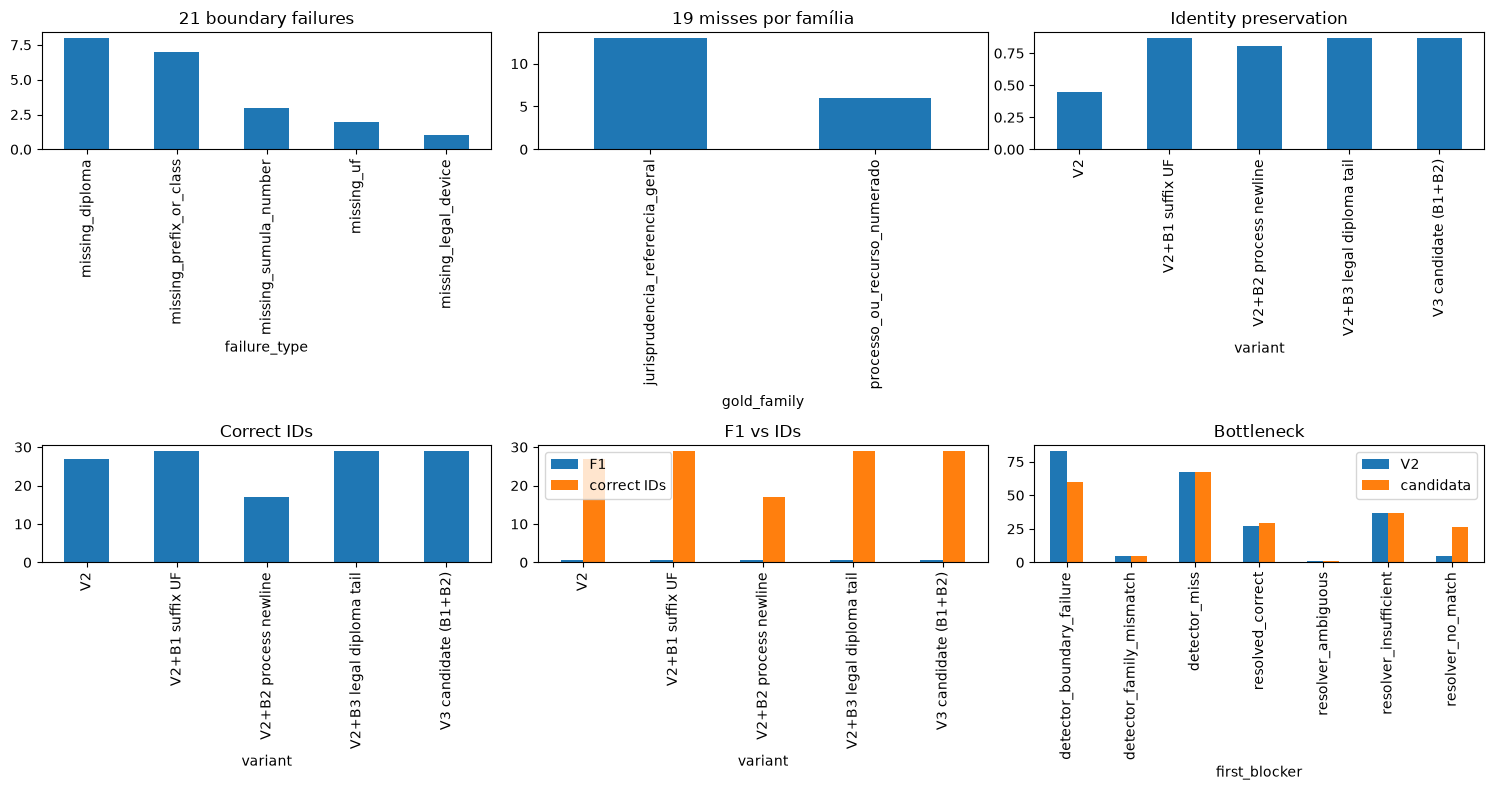

In [7]:
# LOODO é medida de concentração, não blind holdout; regras não são retreinadas.
def subset_metrics(tr, docs):
    x=tr[tr.documento_id.isin(docs)]; return x.correct.sum(), x.iou.notna().sum()
deltas=[]
for doc in texts:
    keep=set(texts)-{doc}; a=tracking[tracking.documento_id.isin(keep)]; z=best_tracking[best_tracking.documento_id.isin(keep)]
    deltas.append({'documento_id':doc,'delta_correct_ID':int(z.correct.sum()-a.correct.sum()),'delta_F1':float(2*z.iou.notna().sum()/(len(z)+len(gold[gold.documento_id.isin(keep)]))-2*a.iou.notna().sum()/(len(a)+len(gold[gold.documento_id.isin(keep)])))})
loodo=pd.DataFrame(deltas); print('LOODO delta correct min/median/max:',loodo.delta_correct_ID.min(),loodo.delta_correct_ID.median(),loodo.delta_correct_ID.max()); print('LOODO delta F1 min/median/max:',round(loodo.delta_F1.min(),4),round(loodo.delta_F1.median(),4),round(loodo.delta_F1.max(),4))
# três execuções sobre os mesmos textos: assinatura de candidates, parsing e resolução.
def signature():
    p,_=run_candidates(cumulative); return tuple((r.documento_id,r.start,r.end,r.text,r.rule,r.candidate_family,dict(r.parsed.data),r.result.status,r.result.id_canonico) for r in p.itertuples())
sigs=[signature() for _ in range(3)]; assert sigs[0]==sigs[1]==sigs[2]; print('Determinismo: 3/3 execuções idênticas; tempo V2={:.3f}s, V3={:.3f}s.'.format(elapsed,ct))
# Visualizações enxutas solicitadas.
fig,ax=plt.subplots(2,3,figsize=(15,8)); b.failure_type.value_counts().plot.bar(ax=ax[0,0],title='21 boundary failures'); m.gold_family.value_counts().plot.bar(ax=ax[0,1],title='19 misses por família'); report.set_index('variant')['identity rate'].plot.bar(ax=ax[0,2],title='Identity preservation'); report.set_index('variant')['correct IDs'].plot.bar(ax=ax[1,0],title='Correct IDs'); report.set_index('variant')[['F1','correct IDs']].plot.bar(ax=ax[1,1],title='F1 vs IDs'); attribution[['V2','candidata']].plot.bar(ax=ax[1,2],title='Bottleneck'); plt.tight_layout(); plt.show()

## Síntese e decisão

A tabela `report` é a tabela central de variantes; `table_experiment` separa boundary/miss e registra regressões e segurança. `best` é a combinação estrutural B1+B2 somente se permanecer segura.

### Identity Preservation baseline
O denominador é o número de gold citations matched pelo detector; a taxa é calculada sobre os campos relevantes disponíveis no oracle. A Resolution Preservation baseline é explicitamente `27/41 = 65,9%` quando reproduzida.

### Decisão
PROMOTE NOW somente mecanismos LOW/MODERATE com ganho distribuído, zero regressões e zero falsos reais. Ganhos apenas em identidade de CNJ/legal ficam como `KEEP FOR RESOLVER/PARSER FUTURE`; mecanismos concentrados, sem suporte estrutural ou que geram FP inseguro são `REJECT`.

### O que o Notebook 13 esclareceu
As respostas quantitativas às 13 perguntas estão nas tabelas e asserts acima: 21 boundary failures, 5 family mismatches, 19 misses, high-value misses oracle-resolvable, IDs recuperados, F1 versus correct IDs, segurança, distribuição N1/N2, LOODO, attribution e bottleneck shift. A menor V3 justificável é a união apenas das mudanças com ganho E2E e segurança comprovada; se não houver ganho, a decisão é continuar explorando Detector ou voltar ao Resolver conforme `best['correct IDs']` e o gargalo exibido.

### Escopo
Nenhum arquivo de produção, banco, gold, CaseIndex no detector experimental, FTS, modelo, filtro de candidates ou normalização OCR global foi alterado.